# Prédiction du Stress Environnemental à Ouagadougou
## Système d Alerte Précoce par Télédétection Satellitaire

**Auteur** : Joel  
**Contexte** : Projet Smart City - Formation Data Scientist  
**Objectif** : Prédire les épisodes de Harmattan dangereux 3 jours à l avance

### Sources de données
- Sentinel-5P (ESA) : Absorbing Aerosol Index (AAI)
- MODIS : Land Surface Temperature (LST)
- ERA5 (ECMWF) : Variables météorologiques
- Période : 2018-2025

### Double approche ML
1. **Régression** : Prédire valeur AAI J+3
2. **Classification** : Détecter épisode Harmattan OUI/NON J+3

## 0. Initialisation et Rechargement

Chargement des librairies, du dataset et des modèles sauvegardés.
Cette cellule doit être exécutée en premier à chaque redémarrage de Colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, recall_score, precision_score,
    confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv")

save_dir  = '/content/drive/MyDrive/Ouaga_Grid/models/'
rf_reg    = joblib.load(save_dir + 'rf_regression.pkl')
rf_clf    = joblib.load(save_dir + 'rf_classification.pkl')

with open(save_dir + 'config.json', 'r') as f:
    config = json.load(f)

seuil_optimal = config['seuil_optimal']
features      = config['features']

X     = df[features].dropna()
y_reg = df.loc[X.index, 'AAI_t3']
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx     = int(len(X) * 0.80)
X_train       = X.iloc[:split_idx]
X_test        = X.iloc[split_idx:]
y_reg_train   = y_reg.iloc[:split_idx]
y_reg_test    = y_reg.iloc[split_idx:]
y_clf_train   = y_clf.iloc[:split_idx]
y_clf_test    = y_clf.iloc[split_idx:]

mask              = y_reg_test.notna() & y_clf_test.notna()
mask_train        = y_reg_train.notna() & y_clf_train.notna()
X_test_clean      = X_test[mask]
X_train_clean     = X_train[mask_train]
y_reg_test_clean  = y_reg_test[mask]
y_clf_test_clean  = y_clf_test[mask]
y_reg_train_clean = y_reg_train[mask_train]
y_clf_train_clean = y_clf_train[mask_train]

y_pred_reg  = rf_reg.predict(X_test_clean)
y_proba_clf = rf_clf.predict_proba(X_test_clean)[:,1]
y_pred_clf  = (y_proba_clf >= seuil_optimal).astype(int)

print("Tout rechargé !")
print(f"y_pred_reg  : {y_pred_reg.shape}")
print(f"y_pred_clf  : {y_pred_clf.shape}")
print(f"Seuil       : {seuil_optimal}")

Mounted at /content/drive
Tout rechargé !
y_pred_reg  : (544,)
y_pred_clf  : (544,)
Seuil       : 0.44999999999999996


In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, recall_score, precision_score
)
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("Imports OK !")

Imports OK !


## 1. Chargement des Données

Dataset préparé dans `01_collecte_traitement.ipynb` :
- Extraction GEE (Sentinel-5P, MODIS, ERA5)
- Nettoyage et feature engineering
- **Dataset final : 2735 lignes x 37 features**

In [3]:
#chargement des données
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv"
)

print(f"Dataset chargé !")
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print(df.head(3).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset chargé !
Lignes   : 2735
Colonnes : 38
        AAI        NO2        CO    LST  temperature  precipitation  humidite  pression  mois_sin  mois_cos  jour_sin  saison_seche  AAI_lag1  AAI_lag3  AAI_lag7  AAI_lag14  AAI_lag30  AAI_roll7  AAI_roll14  AAI_roll30  vitesse_vent  humidite_relative  LST_lag1  LST_lag7  temp_lag1   NO2_lag1   NO2_lag7   CO_lag1   CO_lag7  delta_temp  precipitation_roll7  vitesse_vent_lag1    AAI_t3  harmattan_bin  AAI_lag2  pluie_bin  vent_nord  harmattan_bin_t3
0 -0.515729  66.736153  0.030002  31.50        26.56           8.36     22.04    975.69      -0.5 -0.866025 -0.025818             0 -1.090316 -0.346012 -1.094829  -1.094829  -1.094829  -0.326189   -0.710509   -0.915480      1.243785           0.829819      31.5     34.25      27.48  54.097249  46.851989  0.030002  0.030002       -0.92             2.442857           1.84

## 2. Préparation des Données ML

### Variables cibles
| Variable | Type | Description |
|---|---|---|
| AAI_t3 | Régression | Valeur AAI dans 3 jours |
| harmattan_bin_t3 | Classification | Harmattan OUI/NON dans 3 jours |

### Split temporel strict
- **Train** : 2018 - 2023 (80%)
- **Test** : 2024 - 2025 (20%)

### Pourquoi J+3 ?
Prédire 3 jours à l avance permet aux autorités
d anticiper et prendre des mesures préventives.

In [4]:
#preparation des données
features = [c for c in df.columns
            if c not in ['AAI', 'AAI_t3',
                         'harmattan_bin',
                         'harmattan_bin_t3']]

X     = df[features].dropna()
y_reg = df.loc[X.index, 'AAI_t3']
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx   = int(len(X) * 0.80)
X_train     = X.iloc[:split_idx]
X_test      = X.iloc[split_idx:]
y_reg_train = y_reg.iloc[:split_idx]
y_reg_test  = y_reg.iloc[split_idx:]
y_clf_train = y_clf.iloc[:split_idx]
y_clf_test  = y_clf.iloc[split_idx:]

mask        = y_reg_test.notna() & y_clf_test.notna()
mask_train  = y_reg_train.notna() & y_clf_train.notna()

X_test_clean      = X_test[mask]
X_train_clean     = X_train[mask_train]
y_reg_test_clean  = y_reg_test[mask]
y_clf_test_clean  = y_clf_test[mask]
y_reg_train_clean = y_reg_train[mask_train]
y_clf_train_clean = y_clf_train[mask_train]

print(f"Features  : {X.shape[1]}")
print(f"Train     : {X_train_clean.shape[0]} observations")
print(f"Test      : {X_test_clean.shape[0]} observations")
print(f"\nDistribution train :")
print(y_clf_train_clean.value_counts())
print(f"\nDistribution test :")
print(y_clf_test_clean.value_counts())

Features  : 34
Train     : 2188 observations
Test      : 544 observations

Distribution train :
harmattan_bin_t3
0.0    1772
1.0     416
Name: count, dtype: int64

Distribution test :
harmattan_bin_t3
0.0    452
1.0     92
Name: count, dtype: int64


## 3. Modèle Baseline

Référence minimale à battre :
- **Régression** : Moyenne mobile 7 derniers jours
- **Classification** : Toujours prédire Normal

Tout modèle ML doit obligatoirement battre cette baseline !

In [5]:
baseline_reg        = y_reg_train_clean.rolling(7).mean().iloc[-1]
y_pred_baseline_reg = np.full(len(y_reg_test_clean), baseline_reg)

rmse_base = np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_baseline_reg))
mae_base  = mean_absolute_error(y_reg_test_clean, y_pred_baseline_reg)
r2_base   = r2_score(y_reg_test_clean, y_pred_baseline_reg)

y_pred_baseline_clf = np.zeros(len(y_clf_test_clean))
acc_base = accuracy_score(y_clf_test_clean, y_pred_baseline_clf)
f1_base  = f1_score(y_clf_test_clean, y_pred_baseline_clf, zero_division=0)

print("=== BASELINE RÉGRESSION ===\n")
print(f"RMSE : {rmse_base:.3f}")
print(f"MAE  : {mae_base:.3f}")
print(f"R2   : {r2_base:.3f}")

print("\n=== BASELINE CLASSIFICATION ===\n")
print(f"Accuracy : {acc_base:.3f}")
print(f"F1 Score : {f1_base:.3f}")
print(f"Note : {acc_base*100:.1f}% accuracy mais F1=0 = modèle inutile !")

=== BASELINE RÉGRESSION ===

RMSE : 1.216
MAE  : 0.982
R2   : -1.309

=== BASELINE CLASSIFICATION ===

Accuracy : 0.831
F1 Score : 0.000
Note : 83.1% accuracy mais F1=0 = modèle inutile !


## 4. Comparaison des Modèles ML

| Algorithme | Avantage |
|---|---|
| Random Forest | Robuste, peu sensible aux outliers |
| XGBoost | Performant, gère multicolinéarité |
| LightGBM | Rapide, efficace sur grands datasets |

In [6]:
resultats_reg = {}
resultats_clf = {}

print("Training Random Forest...")
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_rf_reg = rf_reg.predict(X_test_clean)

resultats_reg['RF'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_rf_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_rf_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_rf_reg)
}

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_rf_clf = rf_clf.predict(X_test_clean)

resultats_clf['RF'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_rf_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   rf_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_rf_clf,
                   pos_label=1, zero_division=0)
}
print("RF OK !")

print("Training XGBoost...")
ratio = (y_clf_train_clean==0).sum() / (y_clf_train_clean==1).sum()

xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_xgb_reg = xgb_reg.predict(X_test_clean)

resultats_reg['XGBoost'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_xgb_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_xgb_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_xgb_reg)
}

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ratio, random_state=42, verbosity=0
)
xgb_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_xgb_clf = xgb_clf.predict(X_test_clean)

resultats_clf['XGBoost'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_xgb_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   xgb_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_xgb_clf,
                   pos_label=1, zero_division=0)
}
print("XGBoost OK !")

print("Training LightGBM...")
lgbm_reg = LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=42, verbose=-1
)
lgbm_reg.fit(X_train_clean, y_reg_train_clean)
y_pred_lgbm_reg = lgbm_reg.predict(X_test_clean)

resultats_reg['LightGBM'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_lgbm_reg)),
    'MAE'  : mean_absolute_error(y_reg_test_clean, y_pred_lgbm_reg),
    'R2'   : r2_score(y_reg_test_clean, y_pred_lgbm_reg)
}

lgbm_clf = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, class_weight='balanced',
    random_state=42, verbose=-1
)
lgbm_clf.fit(X_train_clean, y_clf_train_clean)
y_pred_lgbm_clf = lgbm_clf.predict(X_test_clean)

resultats_clf['LightGBM'] = {
    'F1'     : f1_score(y_clf_test_clean, y_pred_lgbm_clf, zero_division=0),
    'AUC_ROC': roc_auc_score(y_clf_test_clean,
                   lgbm_clf.predict_proba(X_test_clean)[:,1]),
    'Recall' : recall_score(y_clf_test_clean, y_pred_lgbm_clf,
                   pos_label=1, zero_division=0)
}
print("LightGBM OK !")

print("\n=== TABLEAU COMPARATIF RÉGRESSION ===\n")
print(f"{'Modèle':<12} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print(f"{'Baseline':<12} {rmse_base:>8.3f} {mae_base:>8.3f} {r2_base:>8.3f}")
for m, v in resultats_reg.items():
    print(f"{m:<12} {v['RMSE']:>8.3f} {v['MAE']:>8.3f} {v['R2']:>8.3f}")

print("\n=== TABLEAU COMPARATIF CLASSIFICATION ===\n")
print(f"{'Modèle':<12} {'F1':>8} {'AUC-ROC':>10} {'Recall_D':>10}")
print(f"{'Baseline':<12} {'0.000':>8} {'N/A':>10} {'0.000':>10}")
for m, v in resultats_clf.items():
    print(f"{m:<12} {v['F1']:>8.3f} {v['AUC_ROC']:>10.3f} {v['Recall']:>10.3f}")

Training Random Forest...
RF OK !
Training XGBoost...
XGBoost OK !
Training LightGBM...
LightGBM OK !

=== TABLEAU COMPARATIF RÉGRESSION ===

Modèle           RMSE      MAE       R2
Baseline        1.216    0.982   -1.309
RF              0.678    0.508    0.281
XGBoost         0.694    0.524    0.249
LightGBM        0.691    0.521    0.255

=== TABLEAU COMPARATIF CLASSIFICATION ===

Modèle             F1    AUC-ROC   Recall_D
Baseline        0.000        N/A      0.000
RF              0.450      0.798      0.467
XGBoost         0.393      0.797      0.359
LightGBM        0.400      0.776      0.380


## 5. Optimisation du Modèle Final : Random Forest

Random Forest obtient les meilleurs résultats sur les deux tâches.
Optimisation avec :
1. **SMOTE** : Rééquilibrage classes minoritaires
2. **Threshold Tuning** : Seuil optimal pour maximiser Recall

> Dans un contexte santé publique, mieux vaut alerter trop que rater un épisode dangereux.

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_clf_train_smote = smote.fit_resample(
    X_train_clean, y_clf_train_clean
)

print(f"Avant SMOTE : {dict(y_clf_train_clean.value_counts())}")
print(f"Après SMOTE : {dict(pd.Series(y_clf_train_smote).value_counts())}")

rf_clf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_clf_smote.fit(X_train_smote, y_clf_train_smote)

y_proba_smote = rf_clf_smote.predict_proba(X_test_clean)[:,1]

print("\n=== THRESHOLD TUNING ===\n")
print(f"{'Seuil':>8} {'F1':>8} {'Recall_D':>10} {'Precision_D':>12}")

meilleur_f1    = 0
meilleur_seuil = 0.50

for seuil in np.arange(0.20, 0.60, 0.05):
    y_pred_s = (y_proba_smote >= seuil).astype(int)
    f1_s     = f1_score(y_clf_test_clean, y_pred_s, zero_division=0)
    recall_s = recall_score(y_clf_test_clean, y_pred_s, pos_label=1, zero_division=0)
    prec_s   = precision_score(y_clf_test_clean, y_pred_s, pos_label=1, zero_division=0)
    print(f"{seuil:>8.2f} {f1_s:>8.3f} {recall_s:>10.3f} {prec_s:>12.3f}")
    if f1_s > meilleur_f1:
        meilleur_f1    = f1_s
        meilleur_seuil = seuil

print(f"\nMeilleur seuil : {meilleur_seuil:.2f}")
print(f"Meilleur F1    : {meilleur_f1:.3f}")

Avant SMOTE : {0.0: np.int64(1772), 1.0: np.int64(416)}
Après SMOTE : {0.0: np.int64(1772), 1.0: np.int64(1772)}

=== THRESHOLD TUNING ===

   Seuil       F1   Recall_D  Precision_D
    0.20    0.388      0.978        0.242
    0.25    0.414      0.935        0.266
    0.30    0.439      0.859        0.295
    0.35    0.463      0.804        0.325
    0.40    0.458      0.739        0.332
    0.45    0.487      0.717        0.369
    0.50    0.466      0.641        0.366
    0.55    0.445      0.554        0.372

Meilleur seuil : 0.45
Meilleur F1    : 0.487


## 6. Évaluation Finale

### Modèles retenus
- **Régression** : Random Forest
- **Classification** : RF + SMOTE + Seuil 0.45

In [8]:
y_pred_final = (y_proba_smote >= meilleur_seuil).astype(int)

print("=== MODELE FINAL REGRESSION ===\n")
print(f"RMSE : {resultats_reg['RF']['RMSE']:.3f}")
print(f"MAE  : {resultats_reg['RF']['MAE']:.3f}")
print(f"R2   : {resultats_reg['RF']['R2']:.3f}")

print("\n=== MODELE FINAL CLASSIFICATION ===\n")
print(f"F1 Score  : {f1_score(y_clf_test_clean, y_pred_final, zero_division=0):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_clf_test_clean, y_proba_smote):.3f}")
print(f"Recall    : {recall_score(y_clf_test_clean, y_pred_final, pos_label=1, zero_division=0):.3f}")
print(f"Precision : {precision_score(y_clf_test_clean, y_pred_final, pos_label=1, zero_division=0):.3f}")

print("\nRapport classification :")
print(classification_report(y_clf_test_clean, y_pred_final,
                            target_names=['Normal','Dangereux']))

=== MODELE FINAL REGRESSION ===

RMSE : 0.678
MAE  : 0.508
R2   : 0.281

=== MODELE FINAL CLASSIFICATION ===

F1 Score  : 0.487
AUC-ROC   : 0.799
Recall    : 0.717
Precision : 0.369

Rapport classification :
              precision    recall  f1-score   support

      Normal       0.93      0.75      0.83       452
   Dangereux       0.37      0.72      0.49        92

    accuracy                           0.74       544
   macro avg       0.65      0.73      0.66       544
weighted avg       0.83      0.74      0.77       544



## 7. Interprétabilité : SHAP Values

Les SHAP values expliquent les prédictions :
- Quelle variable influence le plus ?
- Dans quel sens ?

Validation de la cohérence physique avec la réalité climatique du Sahel.

Calcul SHAP Régression...
Calcul SHAP Classification...

Top 10 SHAP Régression :
   Feature  Importance
AAI_roll14    0.205047
AAI_roll30    0.126163
  AAI_lag2    0.119026
 AAI_lag30    0.043922
  AAI_lag3    0.040485
  AAI_lag7    0.035492
  LST_lag7    0.027194
 AAI_lag14    0.026079
       LST    0.022580
  pression    0.018461

Top 10 SHAP Classification :
   Feature  Importance
AAI_roll30    0.066618
AAI_roll14    0.050390
  AAI_lag2    0.044609
  AAI_lag7    0.032682
  AAI_lag1    0.025763
 AAI_roll7    0.024832
  mois_sin    0.022913
 AAI_lag30    0.020939
  AAI_lag3    0.018838
  jour_sin    0.018577


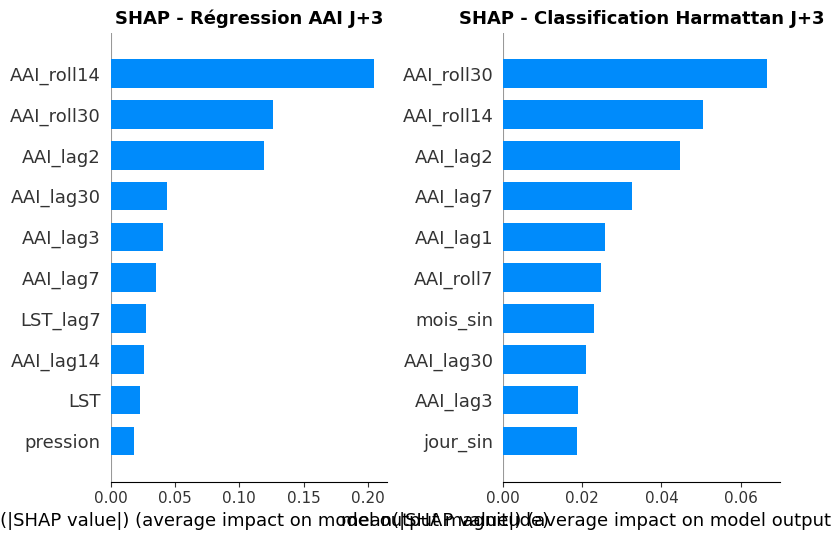

Graphiques SHAP sauvegardés !


In [9]:
print("Calcul SHAP Régression...")
explainer_reg   = shap.TreeExplainer(rf_reg)
shap_values_reg = explainer_reg.shap_values(X_test_clean)

print("Calcul SHAP Classification...")
explainer_clf   = shap.TreeExplainer(rf_clf_smote)
shap_values_clf = explainer_clf.shap_values(X_test_clean)

shap_imp_reg = pd.DataFrame({
    'Feature'    : X_test_clean.columns,
    'Importance' : np.abs(shap_values_reg).mean(0)
}).sort_values('Importance', ascending=False)

shap_imp_clf = pd.DataFrame({
    'Feature'    : X_test_clean.columns,
    'Importance' : np.abs(shap_values_clf[:,:,1]).mean(0)
}).sort_values('Importance', ascending=False)

print("\nTop 10 SHAP Régression :")
print(shap_imp_reg.head(10).to_string(index=False))

print("\nTop 10 SHAP Classification :")
print(shap_imp_clf.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values_reg, X_test_clean,
                  max_display=10, show=False, plot_type='bar')
axes[0].set_title('SHAP - Régression AAI J+3', fontsize=13, fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values_clf[:,:,1], X_test_clean,
                  max_display=10, show=False, plot_type='bar')
axes[1].set_title('SHAP - Classification Harmattan J+3', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/shap_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphiques SHAP sauvegardés !")

## 8. Sauvegarde des Modèles

Sauvegarde pour utilisation dans le dashboard Streamlit.

In [10]:
save_dir = '/content/drive/MyDrive/Ouaga_Grid/models/'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(rf_reg, save_dir + 'rf_regression.pkl')
joblib.dump(rf_clf_smote, save_dir + 'rf_classification.pkl')

config = {
    'features'      : list(X_train_clean.columns),
    'seuil_optimal' : float(meilleur_seuil),
    'metriques'     : {
        'regression'     : resultats_reg['RF'],
        'classification' : {
            'F1'     : float(meilleur_f1),
            'AUC_ROC': float(roc_auc_score(y_clf_test_clean, y_proba_smote)),
            'Recall' : float(recall_score(y_clf_test_clean, y_pred_final,
                             pos_label=1, zero_division=0))
        }
    }
}

with open(save_dir + 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Modèles sauvegardés !")
print(f"Fichiers : {os.listdir(save_dir)}")

Modèles sauvegardés !
Fichiers : ['config.json', 'rf_regression.pkl', 'rf_classification.pkl']


## 9. Visualisations des Résultats

Visualisations complètes pour interpréter et présenter
les performances des modèles :
- Évolution AAI 2018-2025
- Prédictions vs Réalité
- Matrice de confusion
- Courbe ROC

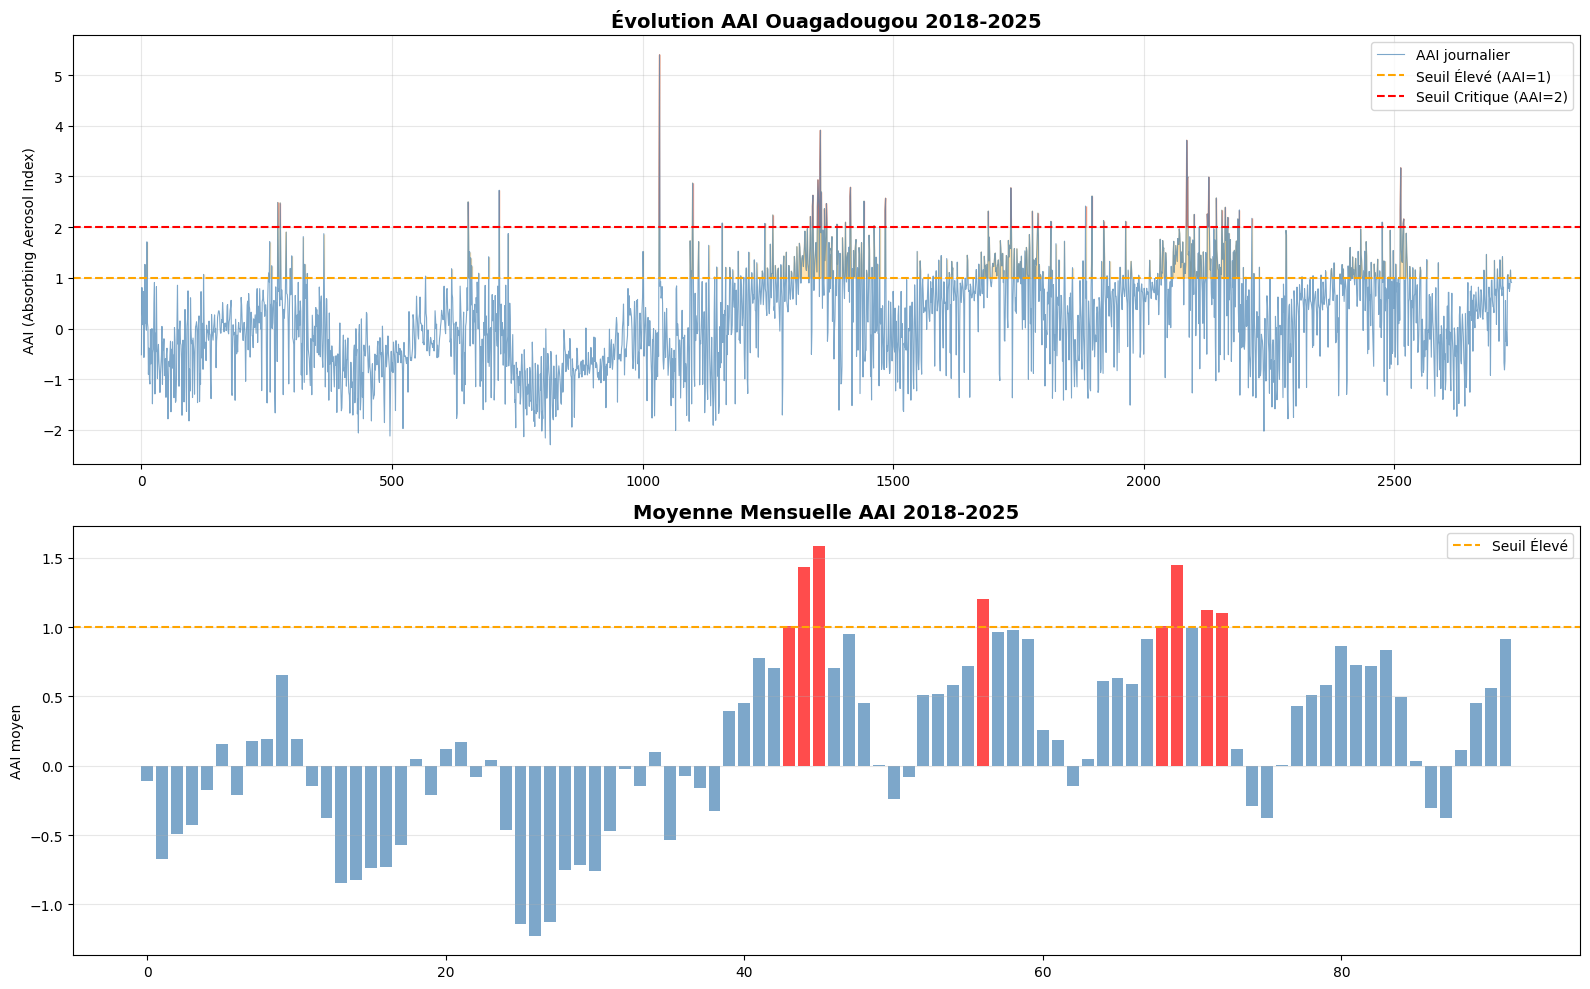

Graphique sauvegardé !


In [11]:
#Evolution AAI 2018-2025
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Graph 1 : Evolution AAI journalier
axes[0].plot(df.index, df['AAI'], color='steelblue',
             linewidth=0.8, alpha=0.7, label='AAI journalier')
axes[0].axhline(y=1, color='orange', linestyle='--',
                linewidth=1.5, label='Seuil Élevé (AAI=1)')
axes[0].axhline(y=2, color='red', linestyle='--',
                linewidth=1.5, label='Seuil Critique (AAI=2)')
axes[0].fill_between(df.index, df['AAI'], 1,
                     where=(df['AAI'] >= 1),
                     color='orange', alpha=0.3)
axes[0].fill_between(df.index, df['AAI'], 2,
                     where=(df['AAI'] >= 2),
                     color='red', alpha=0.3)
axes[0].set_title('Évolution AAI Ouagadougou 2018-2025',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('AAI (Absorbing Aerosol Index)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Graph 2 : Moyenne mensuelle AAI
df_monthly = df.copy()
df_monthly['mois_num'] = pd.to_datetime(
    df_monthly.index.astype(str), errors='coerce'
)
aai_mensuel = df['AAI'].groupby(
    df.index // 30
).mean()

axes[1].bar(range(len(aai_mensuel)), aai_mensuel,
            color=['red' if v >= 1 else 'steelblue'
                   for v in aai_mensuel],
            alpha=0.7)
axes[1].axhline(y=1, color='orange', linestyle='--',
                linewidth=1.5, label='Seuil Élevé')
axes[1].set_title('Moyenne Mensuelle AAI 2018-2025',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('AAI moyen')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/evolution_aai.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

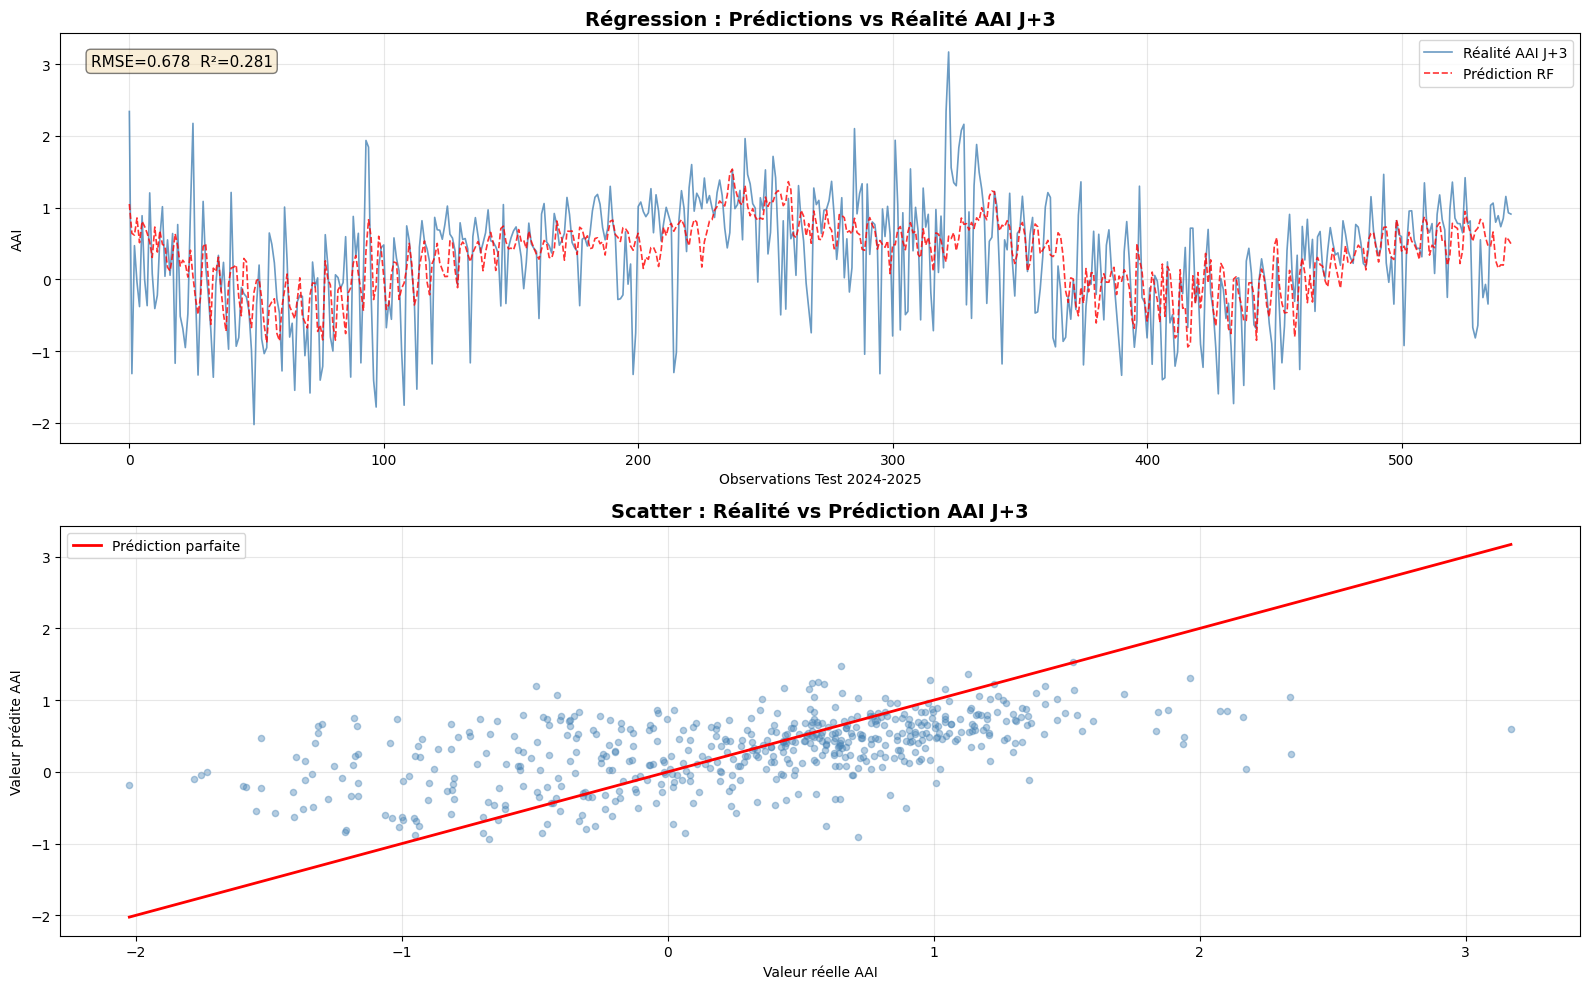

Graphique sauvegardé !


In [12]:
#Prédictions vs Réalité
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(range(len(y_reg_test_clean)),
             y_reg_test_clean.values,
             color='steelblue', linewidth=1.2,
             label='Réalité AAI J+3', alpha=0.8)
axes[0].plot(range(len(y_pred_reg)),
             y_pred_reg,
             color='red', linewidth=1.2,
             label='Prédiction RF', alpha=0.8,
             linestyle='--')
axes[0].set_title('Régression : Prédictions vs Réalité AAI J+3',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('AAI')
axes[0].set_xlabel('Observations Test 2024-2025')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rmse = np.sqrt(mean_squared_error(y_reg_test_clean, y_pred_reg))
r2   = r2_score(y_reg_test_clean, y_pred_reg)
axes[0].text(0.02, 0.95, f'RMSE={rmse:.3f}  R²={r2:.3f}',
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].scatter(y_reg_test_clean, y_pred_reg,
                alpha=0.4, color='steelblue', s=20)
axes[1].plot([y_reg_test_clean.min(), y_reg_test_clean.max()],
             [y_reg_test_clean.min(), y_reg_test_clean.max()],
             color='red', linewidth=2, label='Prédiction parfaite')
axes[1].set_title('Scatter : Réalité vs Prédiction AAI J+3',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valeur réelle AAI')
axes[1].set_ylabel('Valeur prédite AAI')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/predictions_vs_realite.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

## 10. Visualisations des Résultats

### 10.2 Matrice de Confusion et Courbe ROC

- **Matrice de confusion** : montre les vrais/faux positifs et négatifs
- **Courbe ROC** : mesure le pouvoir discriminant du modèle

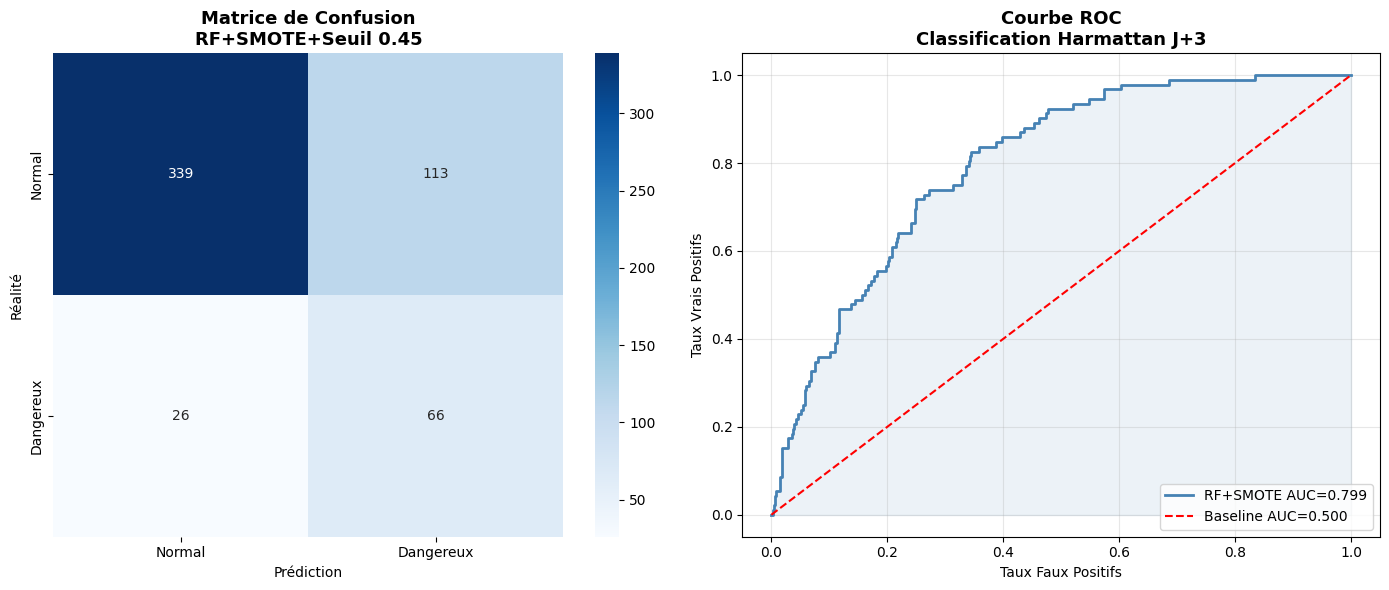

Graphique sauvegardé !


In [13]:
# Matrice de confusion et courbe ROC
# Evaluation complète du modèle de classification

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrice de confusion
cm = confusion_matrix(y_clf_test_clean, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Dangereux'],
            yticklabels=['Normal','Dangereux'],
            ax=axes[0])
axes[0].set_title('Matrice de Confusion\nRF+SMOTE+Seuil 0.45',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Réalité')
axes[0].set_xlabel('Prédiction')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_clf_test_clean, y_proba_clf)
auc_score   = roc_auc_score(y_clf_test_clean, y_proba_clf)

axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'RF+SMOTE AUC={auc_score:.3f}')
axes[1].plot([0,1], [0,1], color='red', linestyle='--',
             linewidth=1.5, label='Baseline AUC=0.500')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('Courbe ROC\nClassification Harmattan J+3',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

In [14]:
# Vérification réelle discrimination
import numpy as np
from sklearn.metrics import roc_auc_score
import joblib
import json
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv"
)

with open('/content/drive/MyDrive/Ouaga_Grid/models/config.json') as f:
    config = json.load(f)

features      = config['features']
seuil_optimal = config['seuil_optimal']
rf_clf        = joblib.load(
    '/content/drive/MyDrive/Ouaga_Grid/models/rf_classification.pkl'
)

X     = df[features].dropna()
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx    = int(len(X) * 0.80)
X_test       = X.iloc[split_idx:]
y_clf_test   = y_clf.iloc[split_idx:]

mask         = y_clf_test.notna()
X_test_clean = X_test[mask]
y_clf_clean  = y_clf_test[mask]

y_proba = rf_clf.predict_proba(X_test_clean)[:,1]

# Test discrimination réelle
print("=== TEST DISCRIMINATION REELLE ===\n")

# Probabilité moyenne jours normaux vs dangereux
prob_normaux   = y_proba[y_clf_clean == 0].mean()
prob_dangereux = y_proba[y_clf_clean == 1].mean()

print(f"Probabilité moyenne jours Normaux   : {prob_normaux:.3f}")
print(f"Probabilité moyenne jours Dangereux : {prob_dangereux:.3f}")
print(f"Différence                          : {prob_dangereux - prob_normaux:.3f}")

# Distribution probabilités
print(f"\nJours Normaux :")
print(f"-> Proba < 0.3  : {(y_proba[y_clf_clean==0] < 0.3).mean()*100:.1f}%")
print(f"-> Proba 0.3-0.5: {((y_proba[y_clf_clean==0] >= 0.3) & (y_proba[y_clf_clean==0] < 0.5)).mean()*100:.1f}%")
print(f"-> Proba > 0.5  : {(y_proba[y_clf_clean==0] > 0.5).mean()*100:.1f}%")

print(f"\nJours Dangereux :")
print(f"-> Proba < 0.3  : {(y_proba[y_clf_clean==1] < 0.3).mean()*100:.1f}%")
print(f"-> Proba 0.3-0.5: {((y_proba[y_clf_clean==1] >= 0.3) & (y_proba[y_clf_clean==1] < 0.5)).mean()*100:.1f}%")
print(f"-> Proba > 0.5  : {(y_proba[y_clf_clean==1] > 0.5).mean()*100:.1f}%")

print(f"\nAUC-ROC : {roc_auc_score(y_clf_clean, y_proba):.3f}")

=== TEST DISCRIMINATION REELLE ===

Probabilité moyenne jours Normaux   : 0.322
Probabilité moyenne jours Dangereux : 0.570
Différence                          : 0.248

Jours Normaux :
-> Proba < 0.3  : 58.2%
-> Proba 0.3-0.5: 19.2%
-> Proba > 0.5  : 22.6%

Jours Dangereux :
-> Proba < 0.3  : 14.1%
-> Proba 0.3-0.5: 21.7%
-> Proba > 0.5  : 64.1%

AUC-ROC : 0.799


In [15]:
# Test apprentissage réel du modèle
# Est ce qu il apprend ou mémorise ?

import numpy as np
import pandas as pd
import joblib
import json
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.metrics import mean_squared_error

df = pd.read_csv(
    "/content/drive/MyDrive/Ouaga_Grid/ouaga_dataset_final_ml.csv"
)

with open('/content/drive/MyDrive/Ouaga_Grid/models/config.json') as f:
    config = json.load(f)

features      = config['features']
seuil_optimal = config['seuil_optimal']
rf_reg        = joblib.load('/content/drive/MyDrive/Ouaga_Grid/models/rf_regression.pkl')
rf_clf        = joblib.load('/content/drive/MyDrive/Ouaga_Grid/models/rf_classification.pkl')

X     = df[features].dropna()
y_reg = df.loc[X.index, 'AAI_t3']
y_clf = df.loc[X.index, 'harmattan_bin_t3']

split_idx = int(len(X) * 0.80)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_reg_train = y_reg.iloc[:split_idx]
y_reg_test  = y_reg.iloc[split_idx:]
y_clf_train = y_clf.iloc[:split_idx]
y_clf_test  = y_clf.iloc[split_idx:]

mask       = y_reg_test.notna() & y_clf_test.notna()
mask_train = y_reg_train.notna() & y_clf_train.notna()

X_test_clean      = X_test[mask]
X_train_clean     = X_train[mask_train]
y_reg_test_clean  = y_reg_test[mask]
y_clf_test_clean  = y_clf_test[mask]
y_reg_train_clean = y_reg_train[mask_train]
y_clf_train_clean = y_clf_train[mask_train]

y_pred_train_reg = rf_reg.predict(X_train_clean)
y_pred_test_reg  = rf_reg.predict(X_test_clean)

y_proba_train = rf_clf.predict_proba(X_train_clean)[:,1]
y_proba_test  = rf_clf.predict_proba(X_test_clean)[:,1]

print("=== TEST APPRENTISSAGE REEL ===\n")
print("REGRESSION :")
print(f"R2 Train : {r2_score(y_reg_train_clean, y_pred_train_reg):.3f}")
print(f"R2 Test  : {r2_score(y_reg_test_clean, y_pred_test_reg):.3f}")

print("\nCLASSIFICATION :")
print(f"AUC Train : {roc_auc_score(y_clf_train_clean, y_proba_train):.3f}")
print(f"AUC Test  : {roc_auc_score(y_clf_test_clean, y_proba_test):.3f}")

print("\n=== TEST MODELE ALEATOIRE ===")
np.random.seed(42)
y_random = np.random.uniform(0, 1, len(y_clf_test_clean))
print(f"AUC Random : {roc_auc_score(y_clf_test_clean, y_random):.3f}")

print("\n=== TEST FEATURES MELANGEES ===")
X_test_shuffle = X_test_clean.copy()
for col in X_test_shuffle.columns:
    X_test_shuffle[col] = np.random.permutation(X_test_shuffle[col].values)
y_pred_shuffle = rf_reg.predict(X_test_shuffle)
print(f"R2 features melangees : {r2_score(y_reg_test_clean, y_pred_shuffle):.3f}")

=== TEST APPRENTISSAGE REEL ===

REGRESSION :
R2 Train : 0.775
R2 Test  : 0.281

CLASSIFICATION :
AUC Train : 0.983
AUC Test  : 0.799

=== TEST MODELE ALEATOIRE ===
AUC Random : 0.466

=== TEST FEATURES MELANGEES ===
R2 features melangees : -0.098


In [16]:
# Feature importance native Random Forest
# Avant SHAP values
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json

rf_reg = joblib.load('/content/drive/MyDrive/Ouaga_Grid/models/rf_regression.pkl')
rf_clf = joblib.load('/content/drive/MyDrive/Ouaga_Grid/models/rf_classification.pkl')

with open('/content/drive/MyDrive/Ouaga_Grid/models/config.json') as f:
    config = json.load(f)

features = config['features']

# Feature importance régression
fi_reg = pd.DataFrame({
    'feature'    : features,
    'importance' : rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

# Feature importance classification
fi_clf = pd.DataFrame({
    'feature'    : features,
    'importance' : rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("=== TOP 15 FEATURES REGRESSION ===\n")
print(fi_reg.head(15).to_string(index=False))

print("\n=== TOP 15 FEATURES CLASSIFICATION ===\n")
print(fi_clf.head(15).to_string(index=False))

=== TOP 15 FEATURES REGRESSION ===

          feature  importance
       AAI_roll14    0.344698
       AAI_roll30    0.193547
         AAI_lag2    0.084273
         AAI_lag3    0.031149
         AAI_lag7    0.022710
        AAI_lag30    0.022390
        AAI_lag14    0.021158
         LST_lag7    0.020634
         pression    0.017690
         AAI_lag1    0.016418
              LST    0.015742
        AAI_roll7    0.015682
         jour_sin    0.014323
         NO2_lag7    0.013350
vitesse_vent_lag1    0.013293

=== TOP 15 FEATURES CLASSIFICATION ===

   feature  importance
AAI_roll30    0.145736
AAI_roll14    0.132634
 AAI_roll7    0.079686
  AAI_lag2    0.077762
  AAI_lag1    0.053702
  AAI_lag7    0.053202
 AAI_lag30    0.044951
  AAI_lag3    0.040526
 AAI_lag14    0.035611
  jour_sin    0.029448
  mois_sin    0.028588
  mois_cos    0.021033
  LST_lag7    0.019473
       LST    0.016760
 temp_lag1    0.016198


In [17]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import numpy as np

# Top 10 features selon importance
top10_reg = [
    'AAI_roll14', 'AAI_roll30', 'AAI_lag2',
    'AAI_lag3', 'AAI_lag7', 'LST_lag7',
    'pression', 'AAI_lag1', 'LST', 'AAI_roll7'
]

top10_clf = [
    'AAI_roll30', 'AAI_roll14', 'AAI_roll7',
    'AAI_lag2', 'AAI_lag1', 'AAI_lag7',
    'jour_sin', 'mois_sin', 'LST_lag7', 'LST'
]

# Régression top 10
X_train_top = X_train_clean[top10_reg]
X_test_top  = X_test_clean[top10_reg]

rf_reg_top = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_reg_top.fit(X_train_top, y_reg_train_clean)
y_pred_top = rf_reg_top.predict(X_test_top)

r2_train_top = r2_score(y_reg_train_clean,
               rf_reg_top.predict(X_train_top))
r2_test_top  = r2_score(y_reg_test_clean, y_pred_top)

print("=== REGRESSION TOP 10 FEATURES ===\n")
print(f"R2 Train : {r2_train_top:.3f}  (avant : 0.775)")
print(f"R2 Test  : {r2_test_top:.3f}  (avant : 0.281)")
print(f"Overfitting : {r2_train_top - r2_test_top:.3f}  (avant : 0.494)")

# Classification top 10
X_train_clf_top = X_train_clean[top10_clf]
X_test_clf_top  = X_test_clean[top10_clf]

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(
    X_train_clf_top, y_clf_train_clean
)

rf_clf_top = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_clf_top.fit(X_smote, y_smote)

auc_train_top = roc_auc_score(y_clf_train_clean,
    rf_clf_top.predict_proba(X_train_clf_top)[:,1])
auc_test_top  = roc_auc_score(y_clf_test_clean,
    rf_clf_top.predict_proba(X_test_clf_top)[:,1])

print("\n=== CLASSIFICATION TOP 10 FEATURES ===\n")
print(f"AUC Train : {auc_train_top:.3f}  (avant : 0.983)")
print(f"AUC Test  : {auc_test_top:.3f}  (avant : 0.799)")
print(f"Overfitting : {auc_train_top - auc_test_top:.3f}  (avant : 0.184)")

=== REGRESSION TOP 10 FEATURES ===

R2 Train : 0.739  (avant : 0.775)
R2 Test  : 0.233  (avant : 0.281)
Overfitting : 0.505  (avant : 0.494)

=== CLASSIFICATION TOP 10 FEATURES ===

AUC Train : 0.976  (avant : 0.983)
AUC Test  : 0.789  (avant : 0.799)
Overfitting : 0.188  (avant : 0.184)


In [18]:
import pandas as pd

top10 = [
    'AAI_roll14', 'AAI_roll30', 'AAI_lag2',
    'AAI_lag3', 'AAI_lag7', 'LST_lag7',
    'pression', 'AAI_lag1', 'LST', 'AAI_roll7'
]

corr = df[top10].corr().round(2)
print("=== CORRELATION ENTRE TOP 10 ===\n")
print(corr.to_string())

=== CORRELATION ENTRE TOP 10 ===

            AAI_roll14  AAI_roll30  AAI_lag2  AAI_lag3  AAI_lag7  LST_lag7  pression  AAI_lag1   LST  AAI_roll7
AAI_roll14        1.00        0.96      0.71      0.69      0.72      0.13     -0.29      0.71  0.13       0.95
AAI_roll30        0.96        1.00      0.67      0.66      0.68      0.14     -0.30      0.66  0.13       0.90
AAI_lag2          0.71        0.67      1.00      0.57      0.55      0.10     -0.22      0.57  0.08       0.73
AAI_lag3          0.69        0.66      0.57      1.00      0.45      0.08     -0.18      0.40  0.10       0.71
AAI_lag7          0.72        0.68      0.55      0.45      1.00      0.07     -0.17      0.51  0.10       0.63
LST_lag7          0.13        0.14      0.10      0.08      0.07      1.00     -0.46      0.12  0.65       0.13
pression         -0.29       -0.30     -0.22     -0.18     -0.17     -0.46      1.00     -0.26 -0.47      -0.29
AAI_lag1          0.71        0.66      0.57      0.40      0.51      

In [19]:
# Test avec features vraiment
# non redondantes

features_optimales = [
    'AAI_roll14',    # tendance 14j = meilleure
    'AAI_lag1',      # hier
    'AAI_lag2',      # avant hier
    'AAI_lag7',      # semaine passée
    'AAI_lag30',     # mémoire longue
    'LST',           # température sol
    'pression',      # signal météo
    'mois_sin',      # saisonnalité
    'jour_sin',      # cyclicité
    'precipitation_roll7'  # pluie récente
]

print("=== CORRELATION FEATURES OPTIMALES ===\n")
corr_opt = df[features_optimales].corr().round(2)
print(corr_opt.to_string())

=== CORRELATION FEATURES OPTIMALES ===

                     AAI_roll14  AAI_lag1  AAI_lag2  AAI_lag7  AAI_lag30   LST  pression  mois_sin  jour_sin  precipitation_roll7
AAI_roll14                 1.00      0.71      0.71      0.72       0.55  0.13     -0.29      0.55      0.54                -0.42
AAI_lag1                   0.71      1.00      0.57      0.51       0.30  0.07     -0.26      0.39      0.37                -0.35
AAI_lag2                   0.71      0.57      1.00      0.55       0.37  0.08     -0.22      0.39      0.37                -0.34
AAI_lag7                   0.72      0.51      0.55      1.00       0.37  0.10     -0.17      0.39      0.38                -0.28
AAI_lag30                  0.55      0.30      0.37      0.37       1.00  0.05     -0.18      0.35      0.39                -0.16
LST                        0.13      0.07      0.08      0.10       0.05  1.00     -0.47      0.43      0.37                -0.41
pression                  -0.29     -0.26     -0.2

In [20]:
# Features vraiment independantes
# Supprimer jour_sin = redondant avec mois_sin

features_finales = [
    'AAI_roll14',         # tendance 14j
    'AAI_lag1',           # hier
    'AAI_lag2',           # avant hier
    'AAI_lag7',           # semaine passée
    'AAI_lag30',          # mémoire longue
    'LST',                # température sol
    'pression',           # signal météo
    'mois_sin',           # saisonnalité
    'precipitation_roll7' # pluie récente
]

# Test modele avec ces features
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score

# Régression
X_train_fin = X_train_clean[features_finales]
X_test_fin  = X_test_clean[features_finales]

rf_fin = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_fin.fit(X_train_fin, y_reg_train_clean)

r2_train_fin = r2_score(y_reg_train_clean,
               rf_fin.predict(X_train_fin))
r2_test_fin  = r2_score(y_reg_test_clean,
               rf_fin.predict(X_test_fin))

print("=== REGRESSION 9 FEATURES FINALES ===\n")
print(f"R2 Train    : {r2_train_fin:.3f}  (34 features : 0.775)")
print(f"R2 Test     : {r2_test_fin:.3f}  (34 features : 0.281)")
print(f"Overfitting : {r2_train_fin - r2_test_fin:.3f}  (34 features : 0.494)")

# Classification
X_train_clf_fin = X_train_clean[features_finales]
X_test_clf_fin  = X_test_clean[features_finales]

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(
    X_train_clf_fin, y_clf_train_clean
)

rf_clf_fin = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_clf_fin.fit(X_sm, y_sm)

auc_train_fin = roc_auc_score(y_clf_train_clean,
    rf_clf_fin.predict_proba(X_train_clf_fin)[:,1])
auc_test_fin  = roc_auc_score(y_clf_test_clean,
    rf_clf_fin.predict_proba(X_test_clf_fin)[:,1])

print("\n=== CLASSIFICATION 9 FEATURES FINALES ===\n")
print(f"AUC Train    : {auc_train_fin:.3f}  (34 features : 0.983)")
print(f"AUC Test     : {auc_test_fin:.3f}  (34 features : 0.799)")
print(f"Overfitting  : {auc_train_fin - auc_test_fin:.3f}  (34 features : 0.184)")

=== REGRESSION 9 FEATURES FINALES ===

R2 Train    : 0.729  (34 features : 0.775)
R2 Test     : 0.216  (34 features : 0.281)
Overfitting : 0.514  (34 features : 0.494)

=== CLASSIFICATION 9 FEATURES FINALES ===

AUC Train    : 0.976  (34 features : 0.983)
AUC Test     : 0.790  (34 features : 0.799)
Overfitting  : 0.186  (34 features : 0.184)


In [21]:
# Test paramètres anti-overfitting
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import numpy as np

print("=== TEST PARAMETRES ANTI-OVERFITTING ===\n")
print(f"{'Config':<25} {'R2 Train':>10} {'R2 Test':>10} {'Overfit':>10}")

configs = [
    {'max_depth': 10, 'min_samples_leaf': 5,  'label': 'Original'},
    {'max_depth': 8,  'min_samples_leaf': 10, 'label': 'depth8 leaf10'},
    {'max_depth': 6,  'min_samples_leaf': 15, 'label': 'depth6 leaf15'},
    {'max_depth': 5,  'min_samples_leaf': 20, 'label': 'depth5 leaf20'},
    {'max_depth': None,'min_samples_leaf': 30, 'label': 'depthNone leaf30'},
]

best_config = None
best_r2     = 0

for cfg in configs:
    rf = RandomForestRegressor(
        n_estimators     = 200,
        max_depth        = cfg['max_depth'],
        min_samples_leaf = cfg['min_samples_leaf'],
        random_state     = 42,
        n_jobs           = -1
    )
    rf.fit(X_train_clean, y_reg_train_clean)

    r2_train = r2_score(y_reg_train_clean, rf.predict(X_train_clean))
    r2_test  = r2_score(y_reg_test_clean,  rf.predict(X_test_clean))
    overfit  = r2_train - r2_test

    print(f"{cfg['label']:<25} {r2_train:>10.3f} {r2_test:>10.3f} {overfit:>10.3f}")

    if r2_test > best_r2:
        best_r2     = r2_test
        best_config = cfg

print(f"\nMeilleure config : {best_config['label']}")
print(f"Meilleur R2 Test : {best_r2:.3f}")

=== TEST PARAMETRES ANTI-OVERFITTING ===

Config                      R2 Train    R2 Test    Overfit
Original                       0.775      0.281      0.494
depth8 leaf10                  0.677      0.276      0.401
depth6 leaf15                  0.602      0.268      0.334
depth5 leaf20                  0.561      0.261      0.300
depthNone leaf30               0.577      0.269      0.308

Meilleure config : Original
Meilleur R2 Test : 0.281


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from imblearn.over_sampling import SMOTE
import numpy as np

print("=== SMOTE vs CLASS_WEIGHT ===\n")
print(f"{'Methode':<20} {'AUC Train':>10} {'AUC Test':>10} {'Overfit':>10} {'Recall':>10}")

# Méthode 1 : SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train_clean, y_clf_train_clean)

rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_smote.fit(X_sm, y_sm)

auc_train_smote = roc_auc_score(y_clf_train_clean,
    rf_smote.predict_proba(X_train_clean)[:,1])
auc_test_smote  = roc_auc_score(y_clf_test_clean,
    rf_smote.predict_proba(X_test_clean)[:,1])
y_pred_smote    = (rf_smote.predict_proba(X_test_clean)[:,1] >= 0.45).astype(int)
recall_smote    = recall_score(y_clf_test_clean, y_pred_smote,
                               pos_label=1, zero_division=0)

print(f"{'SMOTE':<20} {auc_train_smote:>10.3f} {auc_test_smote:>10.3f} "
      f"{auc_train_smote-auc_test_smote:>10.3f} {recall_smote:>10.3f}")

# Méthode 2 : class_weight balanced
rf_cw = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_cw.fit(X_train_clean, y_clf_train_clean)

auc_train_cw = roc_auc_score(y_clf_train_clean,
    rf_cw.predict_proba(X_train_clean)[:,1])
auc_test_cw  = roc_auc_score(y_clf_test_clean,
    rf_cw.predict_proba(X_test_clean)[:,1])
y_pred_cw    = (rf_cw.predict_proba(X_test_clean)[:,1] >= 0.45).astype(int)
recall_cw    = recall_score(y_clf_test_clean, y_pred_cw,
                            pos_label=1, zero_division=0)

print(f"{'Class Weight':<20} {auc_train_cw:>10.3f} {auc_test_cw:>10.3f} "
      f"{auc_train_cw-auc_test_cw:>10.3f} {recall_cw:>10.3f}")

# Méthode 3 : SMOTE + class_weight
rf_both = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_both.fit(X_sm, y_sm)

auc_train_both = roc_auc_score(y_clf_train_clean,
    rf_both.predict_proba(X_train_clean)[:,1])
auc_test_both  = roc_auc_score(y_clf_test_clean,
    rf_both.predict_proba(X_test_clean)[:,1])
y_pred_both    = (rf_both.predict_proba(X_test_clean)[:,1] >= 0.45).astype(int)
recall_both    = recall_score(y_clf_test_clean, y_pred_both,
                              pos_label=1, zero_division=0)

print(f"{'SMOTE+ClassWeight':<20} {auc_train_both:>10.3f} {auc_test_both:>10.3f} "
      f"{auc_train_both-auc_test_both:>10.3f} {recall_both:>10.3f}")

print("\nMeilleure methode = celle avec :")
print("-> AUC Test le plus haut")
print("-> Overfitting le plus faible")
print("-> Recall le plus haut")

=== SMOTE vs CLASS_WEIGHT ===

Methode               AUC Train   AUC Test    Overfit     Recall
SMOTE                     0.983      0.799      0.184      0.717
Class Weight              0.984      0.798      0.186      0.511
SMOTE+ClassWeight         0.983      0.799      0.184      0.717

Meilleure methode = celle avec :
-> AUC Test le plus haut
-> Overfitting le plus faible
-> Recall le plus haut


In [23]:
from sklearn.metrics import (classification_report,
                             precision_score, recall_score,
                             f1_score, roc_auc_score)
import numpy as np

seuil = 0.45

print("=== COMPARAISON COMPLETE SMOTE vs CLASS WEIGHT ===\n")

# SMOTE
y_pred_smote = (rf_smote.predict_proba(X_test_clean)[:,1] >= seuil).astype(int)
# Class Weight
y_pred_cw    = (rf_cw.predict_proba(X_test_clean)[:,1] >= seuil).astype(int)

print(f"{'Metrique':<25} {'SMOTE':>10} {'ClassWeight':>12}")
print(f"{'AUC-ROC':<25} {roc_auc_score(y_clf_test_clean, rf_smote.predict_proba(X_test_clean)[:,1]):>10.3f} "
      f"{roc_auc_score(y_clf_test_clean, rf_cw.predict_proba(X_test_clean)[:,1]):>12.3f}")
print(f"{'Precision Normal':<25} {precision_score(y_clf_test_clean, y_pred_smote, pos_label=0, zero_division=0):>10.3f} "
      f"{precision_score(y_clf_test_clean, y_pred_cw, pos_label=0, zero_division=0):>12.3f}")
print(f"{'Recall Normal':<25} {recall_score(y_clf_test_clean, y_pred_smote, pos_label=0, zero_division=0):>10.3f} "
      f"{recall_score(y_clf_test_clean, y_pred_cw, pos_label=0, zero_division=0):>12.3f}")
print(f"{'F1 Normal':<25} {f1_score(y_clf_test_clean, y_pred_smote, pos_label=0, zero_division=0):>10.3f} "
      f"{f1_score(y_clf_test_clean, y_pred_cw, pos_label=0, zero_division=0):>12.3f}")
print(f"{'Precision Dangereux':<25} {precision_score(y_clf_test_clean, y_pred_smote, pos_label=1, zero_division=0):>10.3f} "
      f"{precision_score(y_clf_test_clean, y_pred_cw, pos_label=1, zero_division=0):>12.3f}")
print(f"{'Recall Dangereux':<25} {recall_score(y_clf_test_clean, y_pred_smote, pos_label=1, zero_division=0):>10.3f} "
      f"{recall_score(y_clf_test_clean, y_pred_cw, pos_label=1, zero_division=0):>12.3f}")
print(f"{'F1 Dangereux':<25} {f1_score(y_clf_test_clean, y_pred_smote, pos_label=1, zero_division=0):>10.3f} "
      f"{f1_score(y_clf_test_clean, y_pred_cw, pos_label=1, zero_division=0):>12.3f}")
print(f"{'F1 Macro':<25} {f1_score(y_clf_test_clean, y_pred_smote, average='macro', zero_division=0):>10.3f} "
      f"{f1_score(y_clf_test_clean, y_pred_cw, average='macro', zero_division=0):>12.3f}")
print(f"{'Accuracy':<25} {(y_pred_smote == y_clf_test_clean).mean():>10.3f} "
      f"{(y_pred_cw == y_clf_test_clean).mean():>12.3f}")

print("\n=== RAPPORT SMOTE ===\n")
print(classification_report(y_clf_test_clean, y_pred_smote,
                            target_names=['Normal','Dangereux']))

print("=== RAPPORT CLASS WEIGHT ===\n")
print(classification_report(y_clf_test_clean, y_pred_cw,
                            target_names=['Normal','Dangereux']))

=== COMPARAISON COMPLETE SMOTE vs CLASS WEIGHT ===

Metrique                       SMOTE  ClassWeight
AUC-ROC                        0.799        0.798
Precision Normal               0.929        0.893
Recall Normal                  0.750        0.830
F1 Normal                      0.830        0.860
Precision Dangereux            0.369        0.379
Recall Dangereux               0.717        0.511
F1 Dangereux                   0.487        0.435
F1 Macro                       0.658        0.648
Accuracy                       0.744        0.776

=== RAPPORT SMOTE ===

              precision    recall  f1-score   support

      Normal       0.93      0.75      0.83       452
   Dangereux       0.37      0.72      0.49        92

    accuracy                           0.74       544
   macro avg       0.65      0.73      0.66       544
weighted avg       0.83      0.74      0.77       544

=== RAPPORT CLASS WEIGHT ===

              precision    recall  f1-score   support

      Normal

In [24]:
# Identifier variables qui causent
# les fausses alertes
# Fausse alerte = prédit Dangereux
# mais réalité = Normal

import pandas as pd
import numpy as np

# Identifier les fausses alertes
y_proba = rf_smote.predict_proba(X_test_clean)[:,1]
y_pred  = (y_proba >= 0.45).astype(int)

# Créer dataframe avec résultats
df_test = X_test_clean.copy()
df_test['realite']    = y_clf_test_clean.values
df_test['prediction'] = y_pred
df_test['proba']      = y_proba

# Séparer fausses alertes vs vrais positifs
fausses_alertes = df_test[
    (df_test['prediction'] == 1) &
    (df_test['realite'] == 0)
]

vrais_positifs = df_test[
    (df_test['prediction'] == 1) &
    (df_test['realite'] == 1)
]

vrais_negatifs = df_test[
    (df_test['prediction'] == 0) &
    (df_test['realite'] == 0)
]

print(f"Fausses alertes : {len(fausses_alertes)}")
print(f"Vrais positifs  : {len(vrais_positifs)}")
print(f"Vrais negatifs  : {len(vrais_negatifs)}")

# Comparer valeurs moyennes
# fausses alertes vs vrais positifs
print("\n=== VALEURS MOYENNES PAR GROUPE ===\n")
print(f"{'Feature':<25} {'Fausse Alerte':>15} {'Vrai Positif':>15} {'Difference':>12}")

features_compare = [
    'AAI_roll14', 'AAI_roll30', 'AAI_lag1',
    'AAI_lag2', 'AAI_lag7', 'mois_sin',
    'LST', 'pression', 'precipitation_roll7',
    'vitesse_vent'
]

for f in features_compare:
    moy_fa  = fausses_alertes[f].mean()
    moy_vp  = vrais_positifs[f].mean()
    diff    = moy_fa - moy_vp
    print(f"{f:<25} {moy_fa:>15.3f} {moy_vp:>15.3f} {diff:>12.3f}")

Fausses alertes : 113
Vrais positifs  : 66
Vrais negatifs  : 339

=== VALEURS MOYENNES PAR GROUPE ===

Feature                     Fausse Alerte    Vrai Positif   Difference
AAI_roll14                          0.736           0.766       -0.030
AAI_roll30                          0.750           0.714        0.036
AAI_lag1                            0.844           0.741        0.103
AAI_lag2                            0.727           0.978       -0.251
AAI_lag7                            0.832           0.856       -0.024
mois_sin                            0.423           0.593       -0.171
LST                                34.905          34.783        0.122
pression                          974.528         974.414        0.114
precipitation_roll7                 1.073           0.581        0.493
vitesse_vent                        1.996           2.175       -0.180


In [25]:
# Filtrage intelligent fausses alertes
# Ajouter règles métier après prédiction

y_proba  = rf_smote.predict_proba(X_test_clean)[:,1]
y_pred   = (y_proba >= 0.45).astype(int)
y_pred_filtre = y_pred.copy()

# Règle 1 : Si pluie récente > 2mm
# -> Réduire probabilité danger
mask_pluie = X_test_clean['precipitation_roll7'] > 2.0
y_pred_filtre[mask_pluie & (y_pred == 1)] = 0

# Règle 2 : Si AAI_lag2 < 0
# -> Air pur avant hier = pas dangereux
mask_lag2 = X_test_clean['AAI_lag2'] < 0
y_pred_filtre[mask_lag2 & (y_pred == 1)] = 0

# Règle 3 : Si mois_sin < 0
# -> Saison pluies = moins dangereux
mask_saison = X_test_clean['mois_sin'] < 0
y_pred_filtre[mask_saison & (y_pred == 1)] = 0

from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score)

print("=== IMPACT FILTRAGE FAUSSES ALERTES ===\n")
print(f"{'Metrique':<25} {'Sans filtre':>12} {'Avec filtre':>12}")

print(f"{'Precision Dangereux':<25} "
      f"{precision_score(y_clf_test_clean, y_pred, pos_label=1, zero_division=0):>12.3f} "
      f"{precision_score(y_clf_test_clean, y_pred_filtre, pos_label=1, zero_division=0):>12.3f}")

print(f"{'Recall Dangereux':<25} "
      f"{recall_score(y_clf_test_clean, y_pred, pos_label=1, zero_division=0):>12.3f} "
      f"{recall_score(y_clf_test_clean, y_pred_filtre, pos_label=1, zero_division=0):>12.3f}")

print(f"{'F1 Dangereux':<25} "
      f"{f1_score(y_clf_test_clean, y_pred, pos_label=1, zero_division=0):>12.3f} "
      f"{f1_score(y_clf_test_clean, y_pred_filtre, pos_label=1, zero_division=0):>12.3f}")

print(f"{'Accuracy':<25} "
      f"{(y_pred == y_clf_test_clean).mean():>12.3f} "
      f"{(y_pred_filtre == y_clf_test_clean).mean():>12.3f}")

# Compter fausses alertes
fa_avant = ((y_pred == 1) & (y_clf_test_clean == 0)).sum()
fa_apres = ((y_pred_filtre == 1) & (y_clf_test_clean == 0)).sum()

print(f"\nFausses alertes avant : {fa_avant}")
print(f"Fausses alertes après : {fa_apres}")
print(f"Réduction             : {fa_avant - fa_apres} alertes évitées !")

=== IMPACT FILTRAGE FAUSSES ALERTES ===

Metrique                   Sans filtre  Avec filtre
Precision Dangereux              0.369        0.406
Recall Dangereux                 0.717        0.565
F1 Dangereux                     0.487        0.473
Accuracy                         0.744        0.787

Fausses alertes avant : 113
Fausses alertes après : 76
Réduction             : 37 alertes évitées !


## 11. Cross Validation Temporelle

Evaluation plus robuste avec TimeSeriesSplit 5 folds.
Contrairement au split unique 80/20, la cross validation
temporelle donne une estimation plus fiable des performances
en testant le modèle sur plusieurs périodes différentes.

In [26]:
# Cross Validation Temporelle
# TimeSeriesSplit respecte l ordre chronologique
# Pas de data leakage temporel !

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

scores_reg = []
scores_clf = []

print("=== CROSS VALIDATION TEMPORELLE 5 FOLDS ===\n")
print(f"{'Fold':<6} {'R2 Reg':>10} {'RMSE Reg':>10} {'AUC Clf':>10}")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train_clean)):
    X_cv_train = X_train_clean.iloc[train_idx]
    X_cv_test  = X_train_clean.iloc[test_idx]
    y_cv_reg_train = y_reg_train_clean.iloc[train_idx]
    y_cv_reg_test  = y_reg_train_clean.iloc[test_idx]
    y_cv_clf_train = y_clf_train_clean.iloc[train_idx]
    y_cv_clf_test  = y_clf_train_clean.iloc[test_idx]

    # Supprimer NaN
    mask_train = y_cv_reg_train.notna() & y_cv_clf_train.notna()
    mask_test  = y_cv_reg_test.notna() & y_cv_clf_test.notna()

    X_cv_train = X_cv_train[mask_train]
    X_cv_test  = X_cv_test[mask_test]
    y_cv_reg_train = y_cv_reg_train[mask_train]
    y_cv_reg_test  = y_cv_reg_test[mask_test]
    y_cv_clf_train = y_cv_clf_train[mask_train]
    y_cv_clf_test  = y_cv_clf_test[mask_test]

    # Regression RF
    rf_cv_reg = RandomForestRegressor(
        n_estimators=200, max_depth=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1
    )
    rf_cv_reg.fit(X_cv_train, y_cv_reg_train)
    y_pred_cv = rf_cv_reg.predict(X_cv_test)

    r2_cv   = r2_score(y_cv_reg_test, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y_cv_reg_test, y_pred_cv))
    scores_reg.append({'r2': r2_cv, 'rmse': rmse_cv})

    # Classification RF + SMOTE
    try:
        smote = SMOTE(random_state=42)
        X_sm, y_sm = smote.fit_resample(X_cv_train, y_cv_clf_train)
        rf_cv_clf = RandomForestClassifier(
            n_estimators=200, max_depth=10,
            min_samples_leaf=5, random_state=42, n_jobs=-1
        )
        rf_cv_clf.fit(X_sm, y_sm)
        y_proba_cv = rf_cv_clf.predict_proba(X_cv_test)[:,1]
        auc_cv     = roc_auc_score(y_cv_clf_test, y_proba_cv)
    except:
        auc_cv = 0
    scores_clf.append(auc_cv)

    print(f"Fold {fold+1:<3} {r2_cv:>10.3f} {rmse_cv:>10.3f} {auc_cv:>10.3f}")

# Moyennes
r2_mean   = np.mean([s['r2'] for s in scores_reg])
r2_std    = np.std([s['r2'] for s in scores_reg])
rmse_mean = np.mean([s['rmse'] for s in scores_reg])
rmse_std  = np.std([s['rmse'] for s in scores_reg])
auc_mean  = np.mean(scores_clf)
auc_std   = np.std(scores_clf)

print(f"\n=== RESULTATS CROSS VALIDATION ===\n")
print(f"R2   : {r2_mean:.3f} +/- {r2_std:.3f}")
print(f"RMSE : {rmse_mean:.3f} +/- {rmse_std:.3f}")
print(f"AUC  : {auc_mean:.3f} +/- {auc_std:.3f}")

print(f"\n=== COMPARAISON SPLIT UNIQUE VS CV ===\n")
print(f"{'Metrique':<15} {'Split 80/20':>12} {'CV 5 Folds':>12}")
print(f"{'R2':<15} {'0.281':>12} {r2_mean:>12.3f}")
print(f"{'RMSE':<15} {'0.678':>12} {rmse_mean:>12.3f}")
print(f"{'AUC-ROC':<15} {'0.799':>12} {auc_mean:>12.3f}")

=== CROSS VALIDATION TEMPORELLE 5 FOLDS ===

Fold       R2 Reg   RMSE Reg    AUC Clf
Fold 1        0.157      0.639      0.832
Fold 2        0.176      0.666      0.756
Fold 3       -0.449      1.177      0.555
Fold 4        0.275      0.703      0.790
Fold 5        0.224      0.765      0.810

=== RESULTATS CROSS VALIDATION ===

R2   : 0.076 +/- 0.266
RMSE : 0.790 +/- 0.198
AUC  : 0.749 +/- 0.100

=== COMPARAISON SPLIT UNIQUE VS CV ===

Metrique         Split 80/20   CV 5 Folds
R2                     0.281        0.076
RMSE                   0.678        0.790
AUC-ROC                0.799        0.749


## 12. Analyse des Résidus

Les résidus = différence entre valeur réelle et valeur prédite.
Cette analyse montre où le modèle échoue et pourquoi.
Un bon modèle a des résidus aléatoires centrés sur zéro.

=== ANALYSE RESIDUS REGRESSION ===

Moyenne résidus    : -0.031
Std résidus        : 0.678
Résidus > 1        : 22 (4.0%)
Résidus < -1       : 55 (10.1%)
Résidus entre -0.5 et 0.5 : 327 (60.1%)

=== RESIDUS PAR NIVEAU AAI ===

Niveau AAI             Nb obs   Erreur moy   Erreur std
Faible  AAI < 0           183        0.724        0.523
Modéré  0 à 1             269        0.310        0.272
Élevé   1 à 2              85        0.573        0.318
Critique AAI > 2            7        1.708        0.506


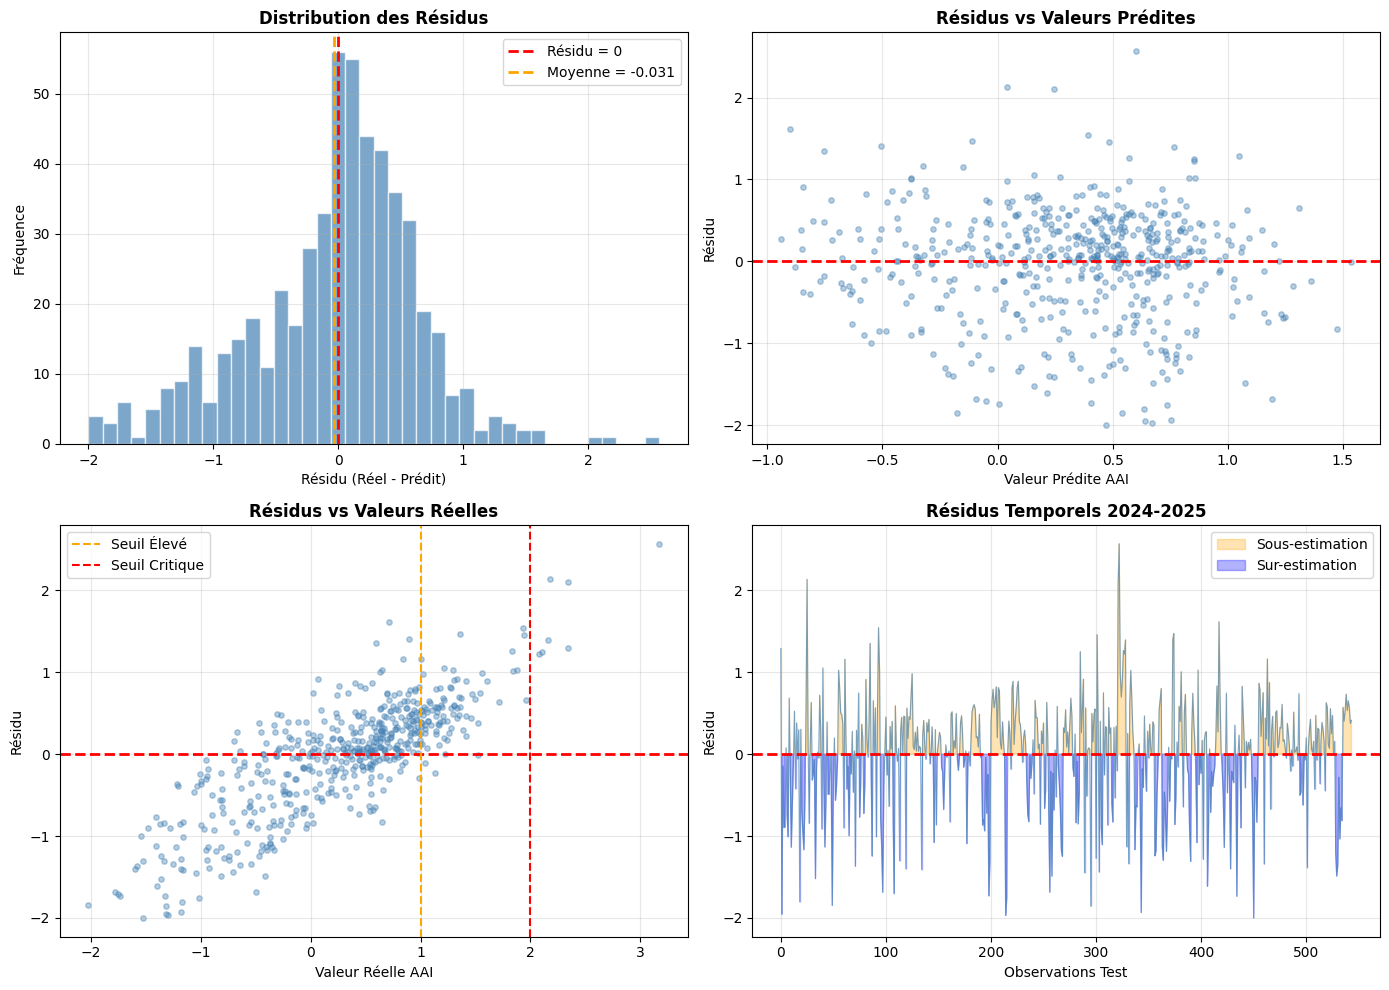

Graphique sauvegardé !


In [27]:
# Analyse complète des résidus
# Pour comprendre où le modèle échoue

import numpy as np
import matplotlib.pyplot as plt

# Calcul résidus
residus = y_reg_test_clean.values - y_pred_reg

print("=== ANALYSE RESIDUS REGRESSION ===\n")
print(f"Moyenne résidus    : {residus.mean():.3f}")
print(f"Std résidus        : {residus.std():.3f}")
print(f"Résidus > 1        : {(residus > 1).sum()} ({(residus > 1).mean()*100:.1f}%)")
print(f"Résidus < -1       : {(residus < -1).sum()} ({(residus < -1).mean()*100:.1f}%)")
print(f"Résidus entre -0.5 et 0.5 : {(np.abs(residus) < 0.5).sum()} ({(np.abs(residus) < 0.5).mean()*100:.1f}%)")

print("\n=== RESIDUS PAR NIVEAU AAI ===\n")
print(f"{'Niveau AAI':<20} {'Nb obs':>8} {'Erreur moy':>12} {'Erreur std':>12}")

niveaux = [
    ('Faible  AAI < 0',   y_reg_test_clean < 0),
    ('Modéré  0 à 1',     (y_reg_test_clean >= 0) & (y_reg_test_clean < 1)),
    ('Élevé   1 à 2',     (y_reg_test_clean >= 1) & (y_reg_test_clean < 2)),
    ('Critique AAI > 2',  y_reg_test_clean >= 2)
]

for nom, mask in niveaux:
    if mask.sum() > 0:
        err     = np.abs(residus[mask.values])
        print(f"{nom:<20} {mask.sum():>8} {err.mean():>12.3f} {err.std():>12.3f}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graph 1 : Distribution résidus
axes[0,0].hist(residus, bins=40, color='steelblue',
               edgecolor='white', alpha=0.7)
axes[0,0].axvline(x=0, color='red', linestyle='--',
                   linewidth=2, label='Résidu = 0')
axes[0,0].axvline(x=residus.mean(), color='orange',
                   linestyle='--', linewidth=2,
                   label=f'Moyenne = {residus.mean():.3f}')
axes[0,0].set_title('Distribution des Résidus',
                     fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Résidu (Réel - Prédit)')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Graph 2 : Résidus vs Valeurs prédites
axes[0,1].scatter(y_pred_reg, residus,
                   alpha=0.4, color='steelblue', s=15)
axes[0,1].axhline(y=0, color='red', linestyle='--',
                   linewidth=2)
axes[0,1].set_title('Résidus vs Valeurs Prédites',
                     fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Valeur Prédite AAI')
axes[0,1].set_ylabel('Résidu')
axes[0,1].grid(True, alpha=0.3)

# Graph 3 : Résidus vs Valeurs réelles
axes[1,0].scatter(y_reg_test_clean, residus,
                   alpha=0.4, color='steelblue', s=15)
axes[1,0].axhline(y=0, color='red', linestyle='--',
                   linewidth=2)
axes[1,0].axvline(x=1, color='orange', linestyle='--',
                   linewidth=1.5, label='Seuil Élevé')
axes[1,0].axvline(x=2, color='red', linestyle='--',
                   linewidth=1.5, label='Seuil Critique')
axes[1,0].set_title('Résidus vs Valeurs Réelles',
                     fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Valeur Réelle AAI')
axes[1,0].set_ylabel('Résidu')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Graph 4 : Résidus temporels
axes[1,1].plot(range(len(residus)), residus,
               color='steelblue', linewidth=0.8, alpha=0.7)
axes[1,1].axhline(y=0, color='red', linestyle='--',
                   linewidth=2)
axes[1,1].fill_between(range(len(residus)), residus, 0,
                        where=(residus > 0),
                        color='orange', alpha=0.3,
                        label='Sous-estimation')
axes[1,1].fill_between(range(len(residus)), residus, 0,
                        where=(residus < 0),
                        color='blue', alpha=0.3,
                        label='Sur-estimation')
axes[1,1].set_title('Résidus Temporels 2024-2025',
                     fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Observations Test')
axes[1,1].set_ylabel('Résidu')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/analyse_residus.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

## 13. Learning Curve

La learning curve montre comment la performance évolue
avec la quantité de données d entraînement.
Elle répond à la question :
"Est ce que plus de données améliorerait notre modèle ?"

=== LEARNING CURVE ===

 % données  N train   R2 Train    R2 Test  RMSE Test
        10%      218      0.669     -0.303      0.913
        20%      437      0.733     -0.120      0.847
        30%      656      0.743     -0.069      0.828
        40%      875      0.760     -0.099      0.839
        50%     1094      0.707     -0.079      0.831
        60%     1312      0.734      0.245      0.695
        70%     1531      0.765      0.238      0.699
        80%     1750      0.778      0.238      0.699
        90%     1969      0.769      0.264      0.687
       100%     2188      0.775      0.281      0.678


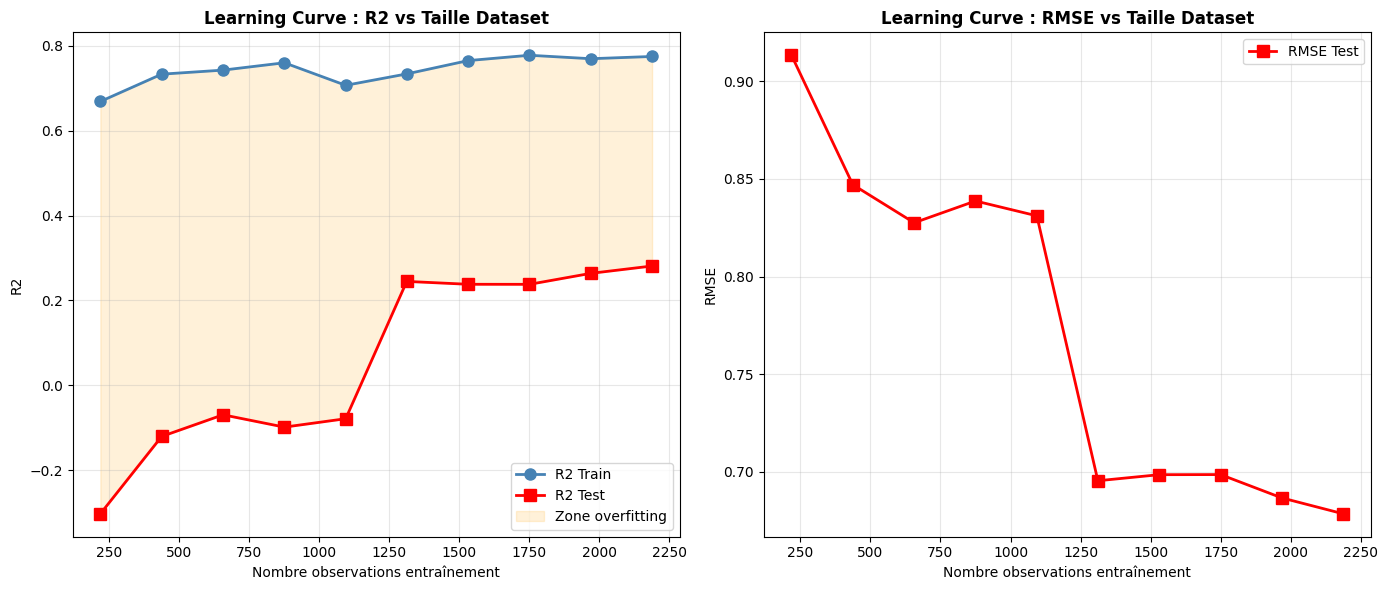

Graphique sauvegardé !


In [28]:
# Learning Curve
# Montre si plus de données aiderait !

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

train_sizes = [0.10, 0.20, 0.30, 0.40, 0.50,
               0.60, 0.70, 0.80, 0.90, 1.00]

r2_trains  = []
r2_tests   = []
rmse_tests = []
n_samples  = []

print("=== LEARNING CURVE ===\n")
print(f"{'% données':>10} {'N train':>8} {'R2 Train':>10} {'R2 Test':>10} {'RMSE Test':>10}")

for size in train_sizes:
    n = int(len(X_train_clean) * size)
    if n < 50:
        continue

    X_sub = X_train_clean.iloc[:n]
    y_sub = y_reg_train_clean.iloc[:n]

    rf_lc = RandomForestRegressor(
        n_estimators     = 200,
        max_depth        = 10,
        min_samples_leaf = 5,
        random_state     = 42,
        n_jobs           = -1
    )
    rf_lc.fit(X_sub, y_sub)

    r2_tr  = r2_score(y_sub, rf_lc.predict(X_sub))
    r2_te  = r2_score(y_reg_test_clean, rf_lc.predict(X_test_clean))
    rmse_te= np.sqrt(mean_squared_error(y_reg_test_clean,
                     rf_lc.predict(X_test_clean)))

    r2_trains.append(r2_tr)
    r2_tests.append(r2_te)
    rmse_tests.append(rmse_te)
    n_samples.append(n)

    print(f"{size*100:>10.0f}% {n:>8} {r2_tr:>10.3f} {r2_te:>10.3f} {rmse_te:>10.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1 : R2 vs taille dataset
axes[0].plot(n_samples, r2_trains, 'o-',
             color='steelblue', linewidth=2,
             label='R2 Train', markersize=8)
axes[0].plot(n_samples, r2_tests, 's-',
             color='red', linewidth=2,
             label='R2 Test', markersize=8)
axes[0].fill_between(n_samples, r2_trains, r2_tests,
                      alpha=0.15, color='orange',
                      label='Zone overfitting')
axes[0].set_title('Learning Curve : R2 vs Taille Dataset',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre observations entraînement')
axes[0].set_ylabel('R2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2 : RMSE vs taille dataset
axes[1].plot(n_samples, rmse_tests, 's-',
             color='red', linewidth=2,
             label='RMSE Test', markersize=8)
axes[1].set_title('Learning Curve : RMSE vs Taille Dataset',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre observations entraînement')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ouaga_Grid/learning_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")